In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (working_directory, *working_directory.parents)
     if (path / "pyproject.toml").is_file() and (path / "src").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from within the project directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
from timesfm3 import TimesFM3Evaluator, ModelConfig
config = ModelConfig(
    checkpoint_path="google/timesfm-3.0-pytorch",
    per_core_batch_size=16,
    device="cuda")
timesfm = TimesFM3Evaluator(config)

In [5]:
import numpy as np
test = np.sin(np.linspace(0, 20, 128)).astype(np.float32)

In [6]:
outputs = list(
    timesfm.predict_batch(
        contexts=[test],
        horizon=24,
        return_quantiles=True,
        use_symmetric_averaging=False))

In [7]:
output = outputs[0]

print(output.forecast.shape)
print(output.quantiles.shape)

(24,)
(24, 9)


In [8]:
from src.data.loader import load_dataset
from src.data.windows import make_last_window

dataset = load_dataset("ETTh1")
window = make_last_window(
    dataset=dataset,
    context_length=512,
    prediction_length=96)

In [9]:
window.history.shape

(512, 7)

In [10]:
context = window.history.T.astype('float32')
context.shape

(7, 512)

In [11]:
outputs = list(
    timesfm.predict_batch(
        contexts=[context],
        horizon=96,
        return_quantiles=True,
        use_symmetric_averaging=False))

In [12]:
output = outputs[0]

print("Forecast:", output.forecast.shape)
print("Quantiles:", output.quantiles.shape)

Forecast: (7, 96)
Quantiles: (7, 96, 9)


In [13]:
from src.models.timesfm import TimesFM3Forecaster
model = TimesFM3Forecaster()

Loading TimesFM 3.0 from google/timesfm-3.0-pytorch on cuda...


TimesFM 3.0 loaded.


In [14]:
forecast = model.predict(history=window.history, prediction_length=96)

In [15]:
print(forecast.predictions.shape)
print(forecast.lower.shape)
print(forecast.upper.shape)

(96, 7)
(96, 7)
(96, 7)


In [16]:
from src.evaluation.experiment import run_single_forecast
result = run_single_forecast(
    forecaster=model,
    dataset_name="ETTh1",
    context_length=512,
    prediction_length=96)


Dataset: ETTh1
History shape: (512, 7)
Target shape: (96, 7)

Prediction shape matches target shape.
Forecast does not contain NaN or infinite values.

seasonal_period has been configured for MASE.
Saved:
- Forecast: results/forecasts/timesfm3_ETTh1_h96.parquet
- Metrics: results/metrics/timesfm3_ETTh1_h96.json


In [17]:
for key, value in result["metrics"].items():
    if key == "mase_per_variable":
        continue
    formatted_value = f"{value:.4f}" if isinstance(value, float) else value
    print(f"{key:25}: {formatted_value}")

mae                      : 1.1141
rmse                     : 1.4913
smape                    : 24.4467
mase                     : 0.8061
dataset                  : ETTh1
model                    : timesfm3
context_length           : 512
prediction_length        : 96
inference_time_seconds   : 0.2889


In [18]:
if "mase_per_variable" in result["metrics"]:
    print("MASE by Variables:")
    for var_name, score in result["metrics"]["mase_per_variable"].items():
        formatted_score = f"{score:.4f}" if isinstance(score, float) else score
        print(f"{var_name:10}: {formatted_score}")

MASE by Variables:
HUFL      : 0.8693
HULL      : 0.9707
MUFL      : 0.8354
MULL      : 0.9733
LUFL      : 0.8719
LULL      : 0.6694
OT        : 0.4524


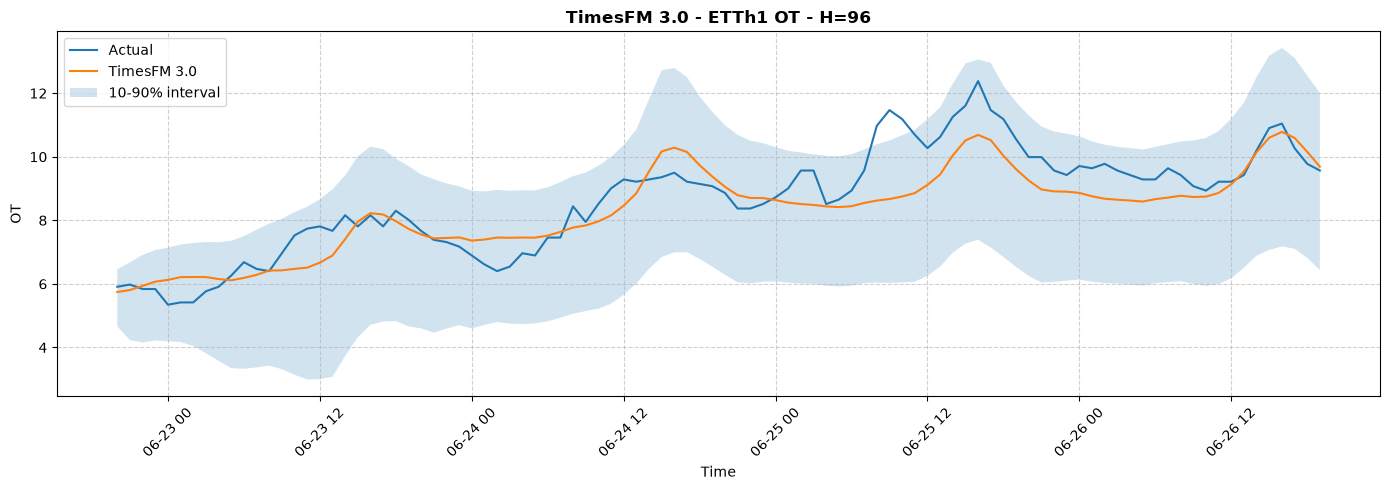

In [19]:
import matplotlib.pyplot as plt

df = result["prediction_df"]
ot = df[df["variable"] == "OT"]

plt.figure(figsize=(14, 5))
plt.plot(ot["timestamp"], ot["actual"], label="Actual")
plt.plot(ot["timestamp"], ot["prediction"], label="TimesFM 3.0")
if {"lower", "upper"}.issubset(ot.columns):
    plt.fill_between(ot["timestamp"], ot["lower"], ot["upper"], alpha=0.2, label="10-90% interval")

plt.title("TimesFM 3.0 - ETTh1 OT - H=96", fontweight="bold")
plt.xlabel("Time")
plt.ylabel("OT")
plt.legend()
plt.grid(True, alpha=0.6, linestyle="--")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../results/figures/timesfm3_ETTh1_h96.png")
plt.show()
